In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re

In [2]:
def no_vp_filename(pp, mbs):
    return f"pp{pp}-MBS{mbs}.log"
def vp_filename(pp, vp, mbs):
    return f"pp{pp}-vp{vp}-MBS{mbs}.log"

In [3]:
iteration_re = re.compile(
    r"iteration\s+(\d+)\s*/\s*(\d+).*?"
    r"throughput per GPU \(TFLOP/s/GPU\):\s*([0-9.]+)\s*\|.*?"
    r"tokens/sec/GPU:\s*([0-9.]+)"
)

memory_re = re.compile(
    r"allocated:\s*([0-9.]+)\s*\|"
    r"\s*max allocated:\s*([0-9.]+)\s*\|"
    r"\s*reserved:\s*([0-9.]+)\s*\|"
    r"\s*max reserved:\s*([0-9.]+)"
)

In [4]:
def get_stats_from_file(fname):
    iterations = []
    tflops = []
    tokens = []
    
    alloc_memory = []
    max_alloc_memory = []
    reserved_memory = []
    max_reserved_memory = []
    
    with open(fname) as f:
        for line in f:
            m = iteration_re.search(line)
            if m:
                iterations.append(int(m.group(1)))
                # m.group(2) is total iterations
                tflops.append(float(m.group(3)))
                tokens.append(float(m.group(4)))
    
            m = memory_re.search(line)
            if m:
                alloc_memory.append(float(m.group(1)))
                max_alloc_memory.append(float(m.group(2)))
                reserved_memory.append(float(m.group(3)))
                max_reserved_memory.append(float(m.group(4)))
    
    # median throughput
    median_tokens = np.median(tokens)

    return median_tokens

In [5]:
baseline_mbss = [1, 2]
pp4_mbss = [1, 2, 4]
pp8_mbss = [1, 2, 4]
pp4_vp2_mbss = [1, 2]
pp4_vp4_mbss = [1, 2]

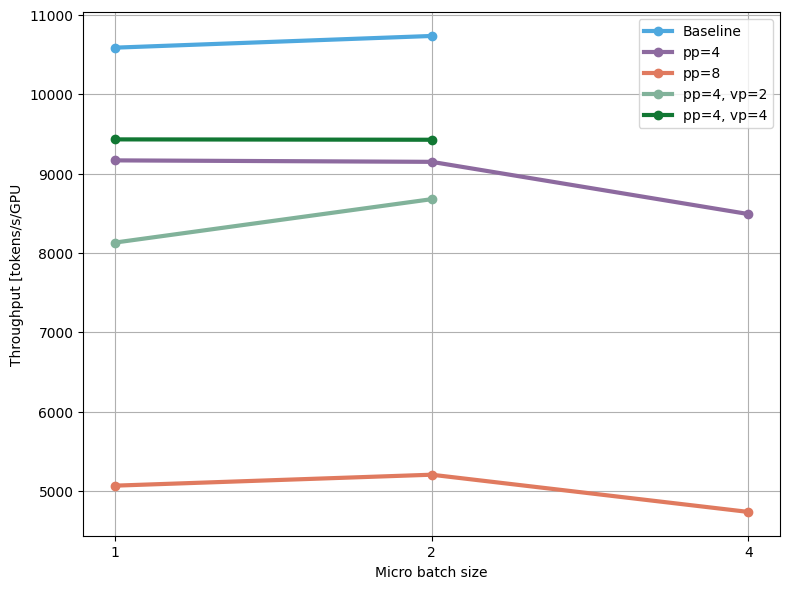

In [12]:
"""
#4EA8DE
#81B29A
#E07A5F
#8D6A9F
#117733
"""
fig = plt.figure(figsize=(8, 6))

# Baseline
baseline_tokens = []
for mbs in baseline_mbss:
    baseline_tokens.append(get_stats_from_file(no_vp_filename(1, mbs)))
baseline_tokens
plt.plot(baseline_mbss, baseline_tokens, marker='o', linewidth=3, label="Baseline", color="#4EA8DE")

# pp4
pp4_tokens = []
for mbs in pp4_mbss:
    pp4_tokens.append(get_stats_from_file(no_vp_filename(4, mbs)))
pp4_tokens
plt.plot(pp4_mbss, pp4_tokens, marker='o', linewidth=3, label="pp=4", color="#8D6A9F")

# pp8
pp8_tokens = []
for mbs in pp8_mbss:
    pp8_tokens.append(get_stats_from_file(no_vp_filename(8, mbs)))
pp8_tokens
plt.plot(pp8_mbss, pp8_tokens, marker='o', linewidth=3, label="pp=8", color="#E07A5F")

# pp4_vp2
pp4_vp2_tokens = []
for mbs in pp4_vp2_mbss:
    pp4_vp2_tokens.append(get_stats_from_file(vp_filename(4, 2, mbs)))
pp4_vp2_tokens
plt.plot(pp4_vp2_mbss, pp4_vp2_tokens, marker='o', linewidth=3, label="pp=4, vp=2", color="#81B29A")

# pp4_vp4
pp4_vp4_tokens = []
for mbs in pp4_vp4_mbss:
    pp4_vp4_tokens.append(get_stats_from_file(vp_filename(4, 4, mbs)))
pp4_vp4_tokens
plt.plot(pp4_vp4_mbss, pp4_vp4_tokens, marker='o', linewidth=3, label="pp=4, vp=4", color="#117733")

plt.xscale("log", base=2)
plt.xlabel("Micro batch size")
plt.ylabel("Throughput [tokens/s/GPU")
plt.xticks([1, 2, 4], [1, 2, 4])
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("pp_throughput.png")
plt.show()